In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker

import freealg
from freealg import AlgebraicForm
from freealg.distributions import MarchenkoPastur, ChiralBlock, CompoundFreePoisson, FreeLevy
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
save_filename = 'fl'
title = 'Free Levy'
latex = True

[(-0.8032258064516131, 0.7838709677419353), (1.1129032258064515, 3.193548387096774), (4.190322580645161, 7.6161290322580655)]


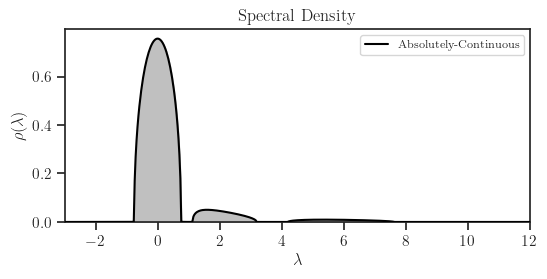

In [2]:
lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75
sigma = 0.4

dist = FreeLevy(t=[t1, t2], w=[w1, 1-w1], lam=lam, a=0.0, sigma=sigma)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=True, save=False)

# Submatrix

In [3]:
# # Create data if not exists
# A = dist.matrix(16000, seed=0)
# eig_A = numpy.linalg.eigvalsh(A)

# As = freealg.submatrix(A, 4000, seed=0)
# eig_As = numpy.linalg.eigvalsh(As)

# out = {
#     'eig_A': eig_A,
#     'eig_As': eig_As,
#     'lam': lam,
#     't': [t1, t2],
#     'w1': w1,
#     'sigma': sigma,
#     'n': A.shape[0],
#     'n0': As.shape[0]
# }

# filename = 'free-levy.npz'
# dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
# out_filename = join(dir_, filename)
# numpy.savez(out_filename, out=numpy.array(out, dtype=object))

In [3]:
# Load data if already created before
filename = 'free-levy.npz'
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
out_filename = join(dir_, filename)

data = numpy.load(out_filename, allow_pickle=True)
out = data['out'].item()

eig_A = out['eig_A']
eig_As = out['eig_As']
n = out['n']
n0 = out['n0']

# Fit Spectral Curve


------------------------------------------
Support (detected from histogram):
	Interval 1: (  -0.3366,    2.6101)

fit residual max  : 6.4085e-05
fit residual 99.9%: 6.4083e-05

Coefficients (real)
+1.00000000 +1.59846295 +0.46211533 +0.07557978 +0.02822104 
+0.00000000 +1.00000000 +1.88610950 +0.70007962 +0.00096569 

Coefficients (imag) norm: 0.0000e+00


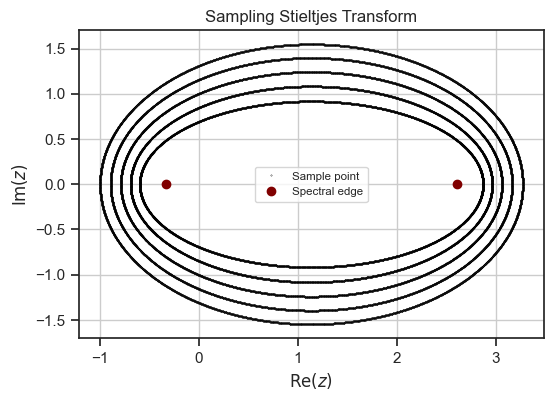

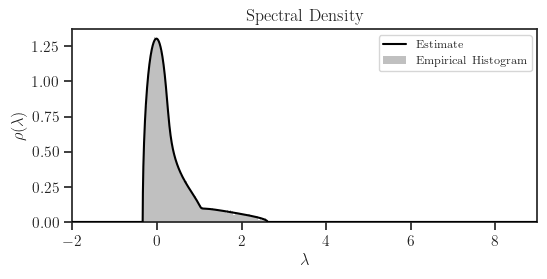


------------------------------------------
Mass: 0.99992652

------------------------------------------
Atoms (estimated from polynomial):

------------------------------------------
is decompressible: True


In [4]:
# Detect support from histogram
support = freealg.supp(eig_As)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')
print('')

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'empirical',   # empirical, asymptotic
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'uniform',  # 'uniform, small_delta
)

# af = AlgebraicForm(dist)
af = AlgebraicForm(eig_As,
                   # support=None,
                   support=support,
                   log=False,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

deg_m = 4
deg_z = 1

# coeffs = af.fit(
#     deg_m, deg_z, reg=0, normalize=True, triangular=(None, None),
#     mu=None, mu_reg=None, verbose=True)

deg_mu = 0
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

coeffs = af.fit(
    deg_m, deg_z,
    reg=0,
    r_min=1.8, r_max=2.5, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096,
    cut_eps=0.01,
    normalize=True,
    triangular=(None, None),
    mu=mu,
    mu_reg=None, verbose=True, plot=True)


x = numpy.linspace(x_min, x_max, 2000)
rho0 = af.density(x, plot=True, latex=latex)

# Check mass (at start size)
print('\n------------------------------------------')
mass = numpy.trapz(rho0, x)
print(f'Mass: {mass:0.8f}')

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

print('\n------------------------------------------')
print('Atoms (estimated from polynomial):')
for i, atom in enumerate(af.atoms()):
    print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')

print('\n------------------------------------------')
status = af.is_decompressible()
print(f'is decompressible: {status}')

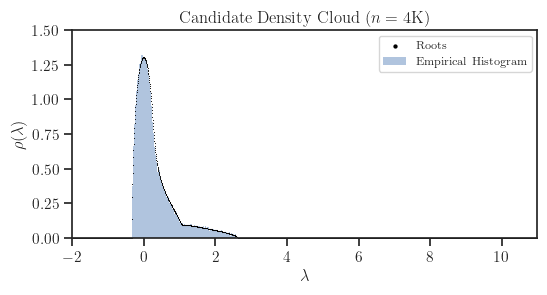

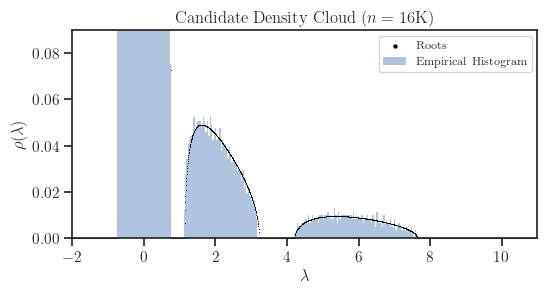

In [5]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = -2
x_max = 11
x_highres = numpy.linspace(x_min, x_max, 2000)

af.candidates(
    size=n0,
    kind='free',
    x=x_highres,
    eig=eig_As,
    delta=None, markersize=0.6, ylim=(0, 1.5), latex=latex)

af.candidates(
    size=n,
    kind='free',
    x=x_highres,
    eig=eig_A,
    delta=None, markersize=0.6, ylim=(0, 0.09), latex=latex)

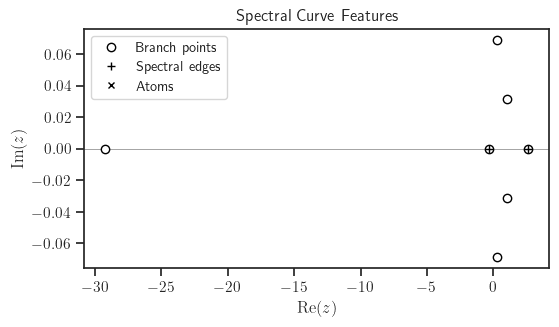


i   Branch Points        Spectral Edge
--  -------------------  -------------
1   -29.2238+0.000e+00i  Maybe
2    +2.6151+0.000e+00i  Maybe
3    +1.0384+3.146e-02i  No
4    +1.0384-3.146e-02i  No
5    -0.3369+0.000e+00i  Maybe
6    +0.2648+6.880e-02i  No
7    +0.2648-6.880e-02i  No


In [6]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

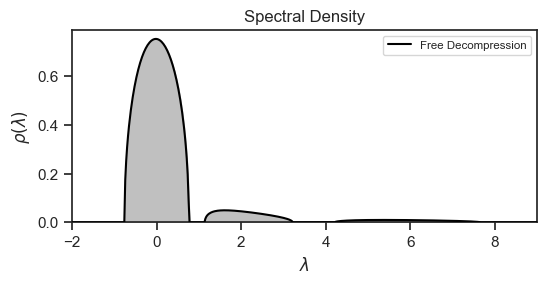

In [5]:
newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-14,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=False,
    pair_enable=True,
    pair_gap_factor=10.0,
)

x = numpy.linspace(x_min, x_max, 500)
# fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)
base = 1000
fd_sizes = base * 2**(numpy.arange(numpy.log2(n0/base), numpy.log2(n/base)+0.01, 0.5))

rho, atoms = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True,
    atom_eps=2e-2,
    verbose=False, plot=True, latex=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/fl-flow.pdf".


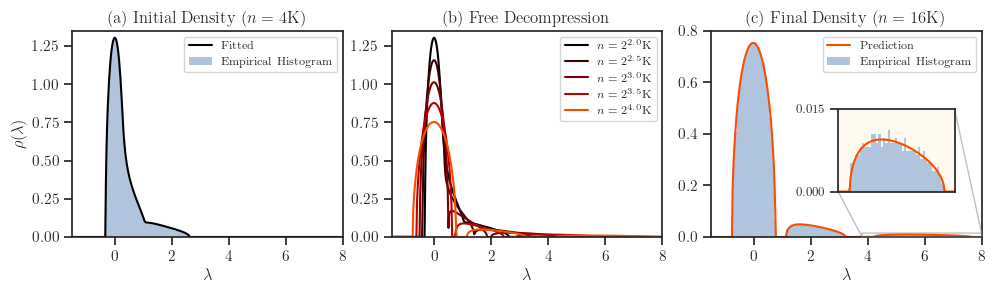

In [6]:
plot_flow(fd_sizes, x, rho, eig_As, eig_A, xlim=[-1.5, 8.0],
          ylim=[(0, 1.35), (0, 1.35), (0, 0.8)], share_ax=False, layout='horizontal',
          title='Free Decompression',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=(60, 100),
          label_mode='pow-dec',
          inset_ax=[2], inset_pos=[0.47, 0.22, 0.43, 0.4], inset_lims=[(3.8, 8), (0, 0.015)],
          save=join(plot_dir, save_filename + '-flow.pdf'),
          latex=latex)

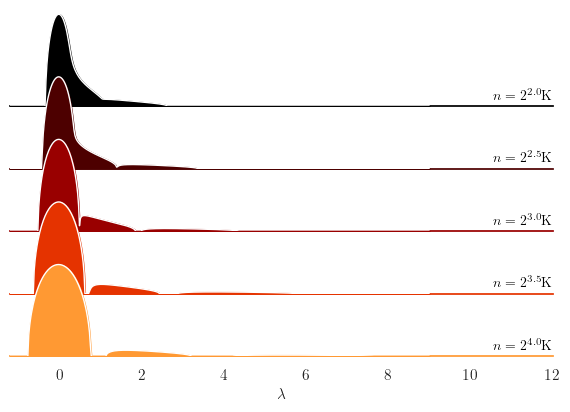

In [7]:
# mask = x > -0.1
# ridgeplot(fd_sizes, x=x[mask], rho=rho[:, mask], eigs=None,
ridgeplot(fd_sizes, x=x, rho=rho, eigs=None,
          log=False, scaley=True, hspace=-0.35, rho_color='white',
          # ylim=(0, 0.01),
          text_side='right', xlim=(-1.2, 12), figsize=(7, 4.5),
          label_mode='pow-dec', latex=latex, save=False, nbins=200)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/fl-mass.pdf".


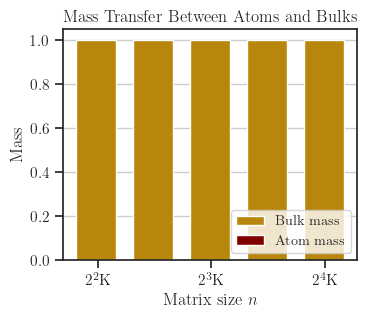

In [8]:
x0 = numpy.linspace(x_min, x_max, 3000)
rho0 = af.density(x0)

plot_mass(fd_sizes, x, rho, x0=x0, rho0=rho0, atoms=atoms, gap=0.7, latex=latex,
          figsize=(3.8, 3),
          log_x=True,
          save=join(plot_dir, save_filename + '-mass.pdf'))

# Edge and Cusp

In [7]:
# fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)
base = 1000
fd_sizes = base * 2**(numpy.arange(numpy.log2(n0/base),
                                   numpy.log2(n/base)+0.01, 0.5))
start_idx = 0
end_idx = fd_sizes.size - 1

t_final = numpy.log(fd_sizes[end_idx] / fd_sizes[start_idx])
t = numpy.linspace(0, t_final, 500)

# cusps, info = af.cusp(t, kind='free', max_iter=100, tol=1e-6,
#                       dedup_t_tol=1e-4, dedup_x_tol=1e-4, return_info=True)

real_merged_edges, cusps = af.edge(
    t, kind='free', supp=support, dt_max=0.01, max_iter=100, tol=1e-12)

print('Cusps:')
if len(cusps) > 0:
    for cusp in cusps:
        print(f'\tx: {cusp[0]:>0.3f}, t: {cusp[1]:>0.3f}')

Cusps:
	x: 1.344, t: 0.299
	x: 0.466, t: 0.645


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/fl-edge.pdf".


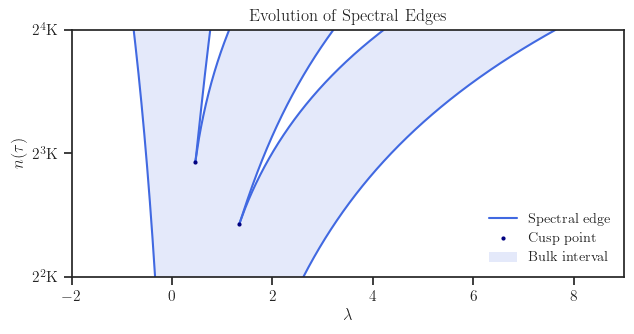

In [9]:
plot_edges(t, real_merged_edges, cusps=cusps,
           sizes=fd_sizes,
           # sizes=None,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           figsize=None, annotate=False,
           xlim=(-2, 9), log_x=False, log_y=True, flip_y=False,
           save=join(plot_dir, save_filename + '-edge.pdf'), latex=latex)

In [10]:
# fd_sizes_plot = numpy.geomspace(sizes[start_idx], sizes[end_idx], t.size)
fd_sizes_plot = numpy.geomspace(n0, n, t.size)

rho_plot, _ = af.decompress(
    fd_sizes_plot, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True,
    atom_eps=1e-2, verbose=False, plot=False, latex=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/fl-edge.pdf".


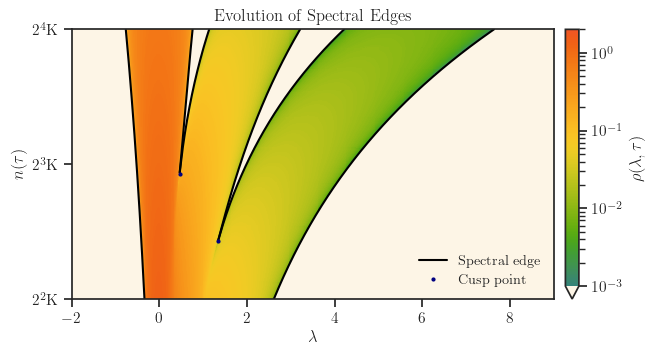

In [11]:
import colorcet as cc

# poisson = (af.delta / numpy.pi) / (xx**2 + af.delta**2)
r = numpy.copy(rho_plot)
# r = numpy.abs(r)
# r[r < poisson] = numpy.nan
# r[r < poisson] = poisson[r < poisson]

# r[(r < 1e-7) & numpy.logical_not(near_cusp)] = numpy.nan
# r[(numpy.abs(r) < 1e-7)] = numpy.nan
r[r < 1e-3] = numpy.nan

# Repair nan points very close to cusp
# near_cusp = (tt_ < 8e3) & (xx > 2e-3) & (xx < 5e-3)
# repair = near_cusp & numpy.isnan(r)
# r[repair] = 1e2 # poisson[repair]
# r[(xx < left_edges[:, None])] = numpy.nan

# cmap = plt.cm.YlOrRd
cmap = cc.cm.CET_R1
# cmap = cc.cm.CET_R4_r
# cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.2, 0.9, 256)))
cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.15, 0.8, 256)))

plot_edges(t, real_merged_edges,
           cusps=cusps,
           # cusps=None,
           sizes=fd_sizes,
           x=x, rho=r, cbar_range=(1e-3, 2), cbar_log=True, cmap=cmap_trim,
           bg_color='oldlace', edge_color='black', fill_color='royalblue', alpha=0.14,
           figsize=(6.8, 3.725), annotate=False, annotate_color='0.3',
           xlim=(-2, 9), log_x=False, log_y=True, flip_y=False,
           save=join(plot_dir, save_filename + '-edge.pdf'), latex=latex)

# Edge and Histogram

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/free-levy-edge-hist.pdf".


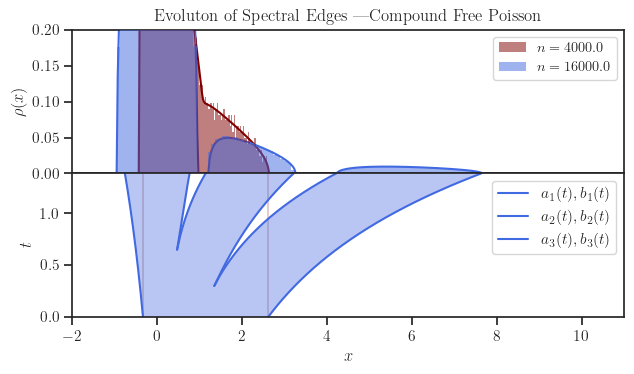

In [106]:
k = real_merged_edges.shape[1] // 2

# colors = ['royalblue', 'maroon']
colors = ['royalblue'] * 5

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.9), nrows=2, sharex=True) 

    # Histogram
    ax[0].hist(eig_As, 100, density=True, zorder=10, alpha=0.5, color='maroon',
               edgecolor='none', label=rf'$n = {{{fd_sizes[0]}}}$')
    ax[0].hist(eig_A, 100, density=True, zorder=10, alpha=0.5, color='royalblue',
               edgecolor='none', label=rf'$n = {{{fd_sizes[-1]}}}$')
    
    ax[0].set_xlim([x[0], x[-1]])
    # ax[0].set_ylim(bottom=0)
    ax[0].set_ylim([0, 0.2])
    # ax[0].set_xlabel(r'$x$')
    ax[0].set_ylabel(r'$\rho(x)$')
    ax[0].set_title(r'Evoluton of Spectral Edges |' + title)
    ax[0].legend(fontsize='small')
    # ax[0].tick_params(labelbottom=False)
    ax[0].tick_params(axis='x', bottom=False, labelbottom=False)

    # rho
    # num_plots = rho.shape[0]
    # cmap = plt.get_cmap('gist_heat')
    # colors = [cmap(i/(num_plots + 2)) for i in range(num_plots + 1)][1:]
    ax[0].plot(x, rho[0], color='maroon')
    ax[0].plot(x, rho[-1], color='royalblue')
    
    for j in range(k):
        a_r = real_merged_edges[:, 2*j + 0]
        b_r = real_merged_edges[:, 2*j + 1]

        a_c = complex_edges[:, 2*j + 0].real
        b_c = complex_edges[:, 2*j + 1].real

        # Plot spectral edges with solid lines
        ax[1].plot(a_r, t, color=colors[j], label=rf'$a_{{{j+1}}}(t), b_{{{j+1}}}(t)$')
        ax[1].plot(b_r, t, color=colors[j])

        # Plot ghost edges with dashed lines
        # m_a = numpy.isnan(a_r)
        # m_b = numpy.isnan(b_r)
        # ax[1].plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
        # ax[1].plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)

        # Fill between
        fill_color = 'royalblue'
        alpha = 0.14
        fill_bulks(ax[1], t, real_merged_edges, color=fill_color, alpha=alpha, zorder=-2)

        ax[1].axvline(a_c[0], color='maroon',alpha=0.2, zorder=-10)
        ax[1].axvline(b_c[0], color='maroon', alpha=0.2, zorder=-10)
        
        # --------
        # Plot I_j
        # --------
        
        # t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.5 * t[-1]
        # j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
        
        # ax[1].annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
        #             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
        
        # ax[1].text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
        #         fr'$I_{{{j+1}}}(t)$',
        #         color='gray', ha='center', va='bottom', fontsize=10)

    # ----------------
    # Plot I_1 cup I_2
    # ----------------
    
    # a_all = real_merged_edges[:, 0]
    # b_all = real_merged_edges[:, -1]

    # t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
    # j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
    
    # ax[1].annotate('', xy=(float(b_all[j_mid2]), t[j_mid2]),
    #                xytext=(float(a_all[j_mid2]), t[j_mid2]),
    #                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    
    # ax[1].text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
    #            # r'$I_1(t) \cup I_2(t)$',
    #            r'$I(t), \quad t < t_{\ast}$',
    #            color='gray', ha='center', va='bottom', fontsize=10)

    # ----
    # Cusp
    # ----
    
    # if 't_cusp' in globals():
    #     ax[1].plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
    #     ax[1].text(x_cusp + 0.15, t_cusp - 0.07, r'$(x_{\ast}, t_{\ast})$', fontsize=10)

    ax[1].set_xlim([x_min, x_max])
    ax[1].set_ylim([t[0], t[-1]])
    ax[1].set_xlabel(r'$x$')
    ax[1].set_ylabel(r'$t$')
    # ax[1].set_title(r'Evolution of Spectral Edges')
    ax[1].legend()

    # --------------
    
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.0)

    save_full_filename = join(plot_dir, save_filename + '-edge-hist.pdf')
    texplot.show_or_save_plot(plt, default_filename=save_full_filename,
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)